[*********************100%***********************]  3 of 3 completed


1149
[0.09909505 0.41937314 0.48153181]
[0.43180154 0.00075331 0.56744515]


<function matplotlib.pyplot.show(close=None, block=None)>

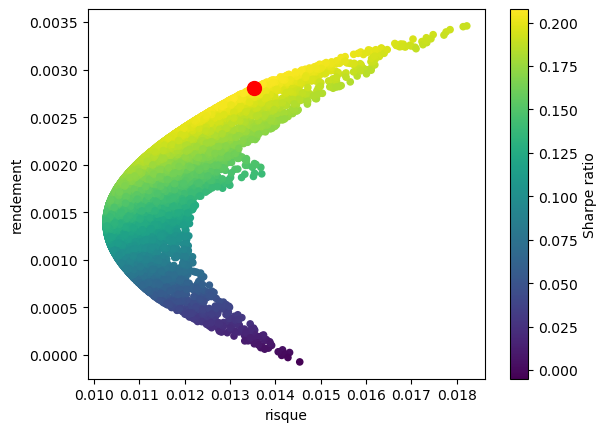

In [16]:
import yfinance as yf
import numpy as np
F=yf.download(['AAPL','MSFT','GOOGL'],period='1y')
Rd=F['Close'].pct_change().dropna()
mu_apple=Rd['AAPL'].mean()
mu_msft=Rd['MSFT'].mean()
mu_google=Rd['GOOGL'].mean()
cov_matrix=Rd[['AAPL','MSFT','GOOGL']].cov()
#combinaison de poids
rd_p=[]
ris_p=[]
sharpe_p=[]
poids_p=[]
for _ in range (10000):
    w=np.random.random(3)
    w=w/w.sum()
    rd=w @ np.array([mu_apple, mu_msft, mu_google])
    var=w @ cov_matrix.values @ w
    ris=np.sqrt(var)
    sh=rd/ris
    rd_p.append(rd)
    ris_p.append(ris)
    sharpe_p.append(sh)
    poids_p.append(w)
#portefeuille optimal 
sharpe_max=np.argmax(sharpe_p)
print(sharpe_max)
print(poids_p[sharpe_max])
#graphe
import matplotlib.pyplot as plt
plt.scatter(ris_p,rd_p,c=sharpe_p,cmap='viridis',s=20)
plt.xlabel('risque')
plt.ylabel('rendement')
plt.colorbar(label='Sharpe ratio')
plt.scatter(ris_p[sharpe_max],rd_p[sharpe_max],color='red',s=100,label='portefeuille optimal')
plt.show